In [18]:
import math
import numpy
import camera_setup as cs
import json
import random
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
robot_coords = []
cam_coords = []
files = ["robo_coords.txt", "saved_coordinates.txt"]

for i in files:
    with open(i, "r") as f:
        if i == "robo_coords.txt":
            lines = f.readlines()
            for i in lines:
                x = json.loads(i)
                robot_coords.append(x)
        
        else:
            lines = f.readlines()
            for i in lines:
                x = json.loads(i)
                cam_coords.append(x)

print(robot_coords)
print(cam_coords)

[[551, 30, 45], [516, -196, 43], [274, -196, 40], [523, 174, 45], [380, -210, 37], [203, -223, 39], [510, 36, 51], [276, -21, 39], [401, 213, 40], [407, -231, 38], [470, 207, 45], [305, 305, 41], [385, -12, 35], [205, 4, 38], [416, -213, 38], [534, -6, 42], [427, 230, 37], [205, 345, 38], [542, -40, 44], [521, 329, 38], [440, -207, 43], [231, -201, 39], [392, 234, 37], [155, 38, 40], [170, 319, 85], [277, -127, 53], [410, 202, 43], [275, 97, 38], [548, -89, 48], [394, 360, 45], [598, 96, 45], [448, -181, 46], [318, 198, 37], [280, -154, 38], [549, 96, 40], [302, 266, 43], [480, 74, 45], [252, -132, 42], [411, 267, 38], [141, 3, 42]]
[[-185.05825805664062, 75.93102264404297, 1068.4498291015625], [-222.66368103027344, 142.612060546875, 1285.5679931640625], [-9.304605484008789, 162.95321655273438, 1343.0235595703125], [-111.55870819091797, 39.310813903808594, 907.1744384765625], [-106.40850830078125, 150.4730682373047, 1335.5623779296875], [44.34828186035156, 177.52671813964844, 1422.4924

In [35]:
count = 3
standard_deviation_list = []
mean_value_list = []
best_rms_list = []
worst_rms_list = []

while count <= 40:
    robot_combinations = []
    cam_combinations = []
    index_list = []
    rms_error_list = []
    
    best_rms = math.inf
    worst_rms = 0
    i = 0
    while i < 5000:
        dummy_robot_list = []
        dummy_cam_list = []
        element_list = []
        while len(element_list) <= count - 1:
            rand_index = random.randint(0,39)
            if rand_index not in element_list:
                element_list.append(rand_index)
        if element_list not in index_list:
            index_list.append(element_list)
            for element in element_list:
                dummy_robot_list.append(robot_coords[element])
                dummy_cam_list.append(cam_coords[element])
            cam_combinations.append(dummy_cam_list)
            robot_combinations.append(dummy_robot_list)
            i += 1
    #print(robot_combinations)
    for i in range(len(cam_combinations)):
        rot,trans =cs.estimate_rigid_transform(cam_combinations[i], robot_combinations[i])
        rms_error = cs.rms_alignment_error(cam_combinations[i], robot_combinations[i], rot, trans)
        rms_error_list.append(rms_error)
        if rms_error < best_rms:
            best_rms = rms_error
            best_rms_index = i
        if rms_error > worst_rms:
            worst_rms = rms_error
            worst_rms_index = i 
    mean_value = numpy.mean(rms_error_list)
    standard_deviation = numpy.std(rms_error_list)
    mean_value_list.append(mean_value)
    standard_deviation_list.append(standard_deviation)
    best_rms_list.append(best_rms)
    worst_rms_list.append(worst_rms)
    print(f"Num_positions:{count}\n Worst RMS:{worst_rms}\n Worst RMS Index:{worst_rms_index}\n Mean RMS: {mean_value}\n Std Deviation: {standard_deviation}\n")
    count += 1
    

Num_positions:3
 Worst RMS:30.73718892713984
 Worst RMS Index:1170
 Mean RMS: 11.74630871322218
 Std Deviation: 4.92964820915714

Num_positions:4
 Worst RMS:43.89472198649992
 Worst RMS Index:954
 Mean RMS: 15.1658261488917
 Std Deviation: 4.98140816378854

Num_positions:5
 Worst RMS:42.117133333447754
 Worst RMS Index:3830
 Mean RMS: 17.332158000126142
 Std Deviation: 5.269663456883923

Num_positions:6
 Worst RMS:40.31211316352053
 Worst RMS Index:4514
 Mean RMS: 18.508563564572686
 Std Deviation: 5.307343963126197

Num_positions:7
 Worst RMS:38.73847503886703
 Worst RMS Index:3270
 Mean RMS: 19.37762323981095
 Std Deviation: 5.269092371473013

Num_positions:8
 Worst RMS:37.49985806557515
 Worst RMS Index:3010
 Mean RMS: 19.850888422124815
 Std Deviation: 5.060120674733673

Num_positions:9
 Worst RMS:36.45968350689291
 Worst RMS Index:2459
 Mean RMS: 20.404928264629515
 Std Deviation: 4.950000865851901

Num_positions:10
 Worst RMS:35.787946925656236
 Worst RMS Index:3551
 Mean RMS: 21

In [36]:
print(best_rms_list)
print(worst_rms_list)
print(standard_deviation_list)
print(mean_value_list)

[1.1747159048898437, 2.507335675220277, 5.31521803729302, 7.129077544992009, 8.87400315820841, 10.127459825645266, 11.068829984198107, 10.926897811124649, 12.284832908503613, 12.420504502673941, 13.019646279411528, 13.672154435380738, 13.197648863357593, 14.108484991478447, 14.455516731886847, 14.863924255896956, 14.488695015397656, 15.475308196404136, 15.174315997304605, 15.295684729385624, 16.218393972978767, 15.717122310199068, 16.28598778585196, 16.61054030826236, 16.336688432526344, 16.94155722153658, 17.25443308041558, 17.53649290517873, 17.37497350991473, 17.710441422150822, 17.57940414962123, 17.980577710395398, 18.16287005399215, 18.131495806004594, 18.71659007135046, 18.978995890002057, 19.996690368559257, 24.31767966549951]
[30.73718892713984, 43.89472198649992, 42.117133333447754, 40.31211316352053, 38.73847503886703, 37.49985806557515, 36.45968350689291, 35.787946925656236, 34.408217825374486, 33.637844411854026, 32.726544989026586, 32.61593513201421, 32.196978822722606, 3

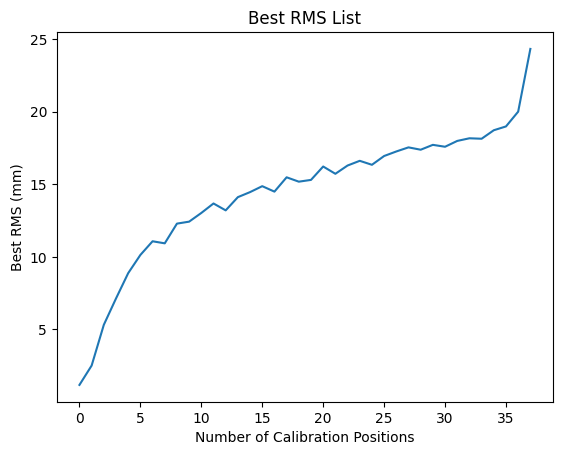

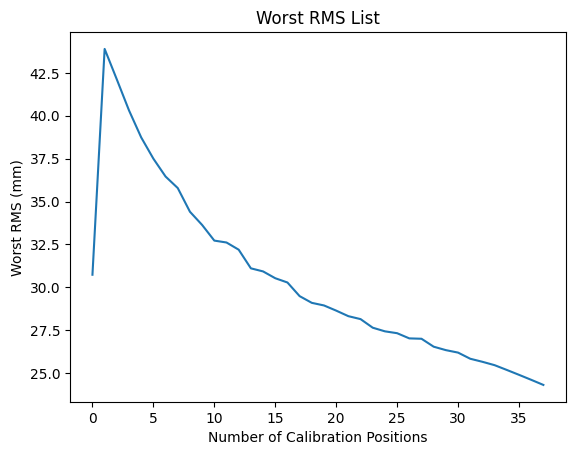

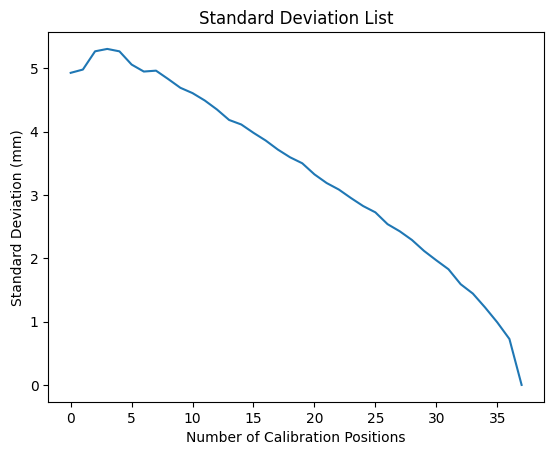

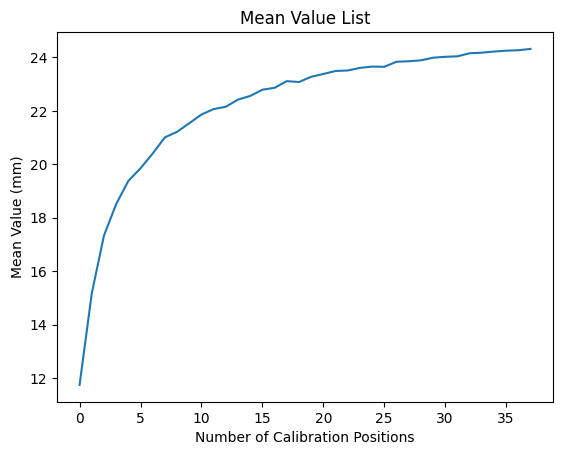

In [38]:
# ---- Plot 1: Best RMS ----
plt.figure()
plt.plot(best_rms_list)
plt.title("Best RMS List")
plt.xlabel("Number of Calibration Positions")
plt.ylabel("Best RMS (mm)")
plt.show()

# ---- Plot 2: Worst RMS ----
plt.figure()
plt.plot(worst_rms_list)
plt.title("Worst RMS List")
plt.xlabel("Number of Calibration Positions")
plt.ylabel("Worst RMS (mm)")
plt.show()

# ---- Plot 3: Standard Deviation ----
plt.figure()
plt.plot(standard_deviation_list)
plt.title("Standard Deviation List")
plt.xlabel("Number of Calibration Positions")
plt.ylabel("Standard Deviation (mm)")
plt.show()

# ---- Plot 4: Mean Value ----
plt.figure()
plt.plot(mean_value_list)
plt.title("Mean Value List")
plt.xlabel("Number of Calibration Positions")
plt.ylabel("Mean Value (mm)")
plt.show()